<!-- CV-PATCHED -->

<a href="https://colab.research.google.com/github/flipiwolker-alt/cv-video-analytics/blob/main/notebooks/PZ_7_LLM__API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ПЗ 7 — Распознавание объектов через OpenRouter (nvidia/nemotron-nano-12b-v2-vl)

Отправляем кадры на FastAPI-сервер (Timeweb, европейский IP), который через OpenRouter вызывает мультимодальную модель `nvidia/nemotron-nano-12b-v2-vl:free` — бесплатно, без региональных ограничений.

In [ ]:
!pip install -q requests pillow tqdm


# Перезапуск runtime в Colab после установки (numpy/torch ABI)
import os, sys
if 'google.colab' in sys.modules:
    print('Перезапуск runtime... выполните следующую ячейку после рестарта.')
    os.kill(os.getpid(), 9)


In [ ]:
# === Общий setup (Colab + локальный fallback) ===
import os, sys, subprocess, warnings, shutil
warnings.filterwarnings('ignore', category=SyntaxWarning)
warnings.filterwarnings('ignore', category=UserWarning)

IN_COLAB = 'google.colab' in sys.modules
USE_DRIVE = IN_COLAB and os.environ.get('CV_USE_DRIVE', '1') == '1'

if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        BASE = '/content/drive/MyDrive/cv-frames'
    except Exception as e:
        print(f'[setup] drive недоступен ({e}) — пишем в /content/cv-frames')
        BASE = '/content/cv-frames'
elif IN_COLAB:
    BASE = '/content/cv-frames'
else:
    BASE = str((os.path.expanduser('~/cv-frames')))

BASE_DRIVE  = BASE
VIDEO_DIR   = f'{BASE}/видио'
FRAMES_DIR  = f'{BASE}/кадры'
RESULTS_DIR = f'{BASE}/результаты'
for d in (VIDEO_DIR, FRAMES_DIR, RESULTS_DIR):
    os.makedirs(d, exist_ok=True)
print(f'[setup] BASE={BASE}')

frames = sorted(f for f in os.listdir(FRAMES_DIR) if f.endswith('.jpg'))
if not frames:
    raise SystemExit(f'нет кадров в {FRAMES_DIR}. Сначала запустите ПЗ 2.')
print(f'кадров всего: {len(frames)}')


In [ ]:
# Два режима работы ПЗ 7:
#   1) прямой вызов OpenRouter, если задан OPENROUTER_API_KEY
#      (export OPENROUTER_API_KEY=... или getpass-ввод ниже);
#   2) если ключа нет — graceful skip с mock-JSON, чтобы ПЗ 8 не сломался.
import os, requests

OPENROUTER_API_KEY = os.environ.get('OPENROUTER_API_KEY', '').strip()
if not OPENROUTER_API_KEY:
    try:
        from getpass import getpass
        OPENROUTER_API_KEY = getpass(
            'OpenRouter API key (Enter — пропустить, сделать mock-результат): '
        ).strip()
    except Exception:
        pass

USE_LLM = bool(OPENROUTER_API_KEY)
print('режим:', 'OpenRouter API' if USE_LLM else 'mock (без ключа)')


In [ ]:
import json, time, base64
from tqdm.notebook import tqdm

OPENROUTER_URL = 'https://openrouter.ai/api/v1/chat/completions'
MODEL = 'nvidia/nemotron-nano-12b-v2-vl:free'
PROMPT = 'List all objects visible in this image, one line, comma separated. Only the list, no explanations.'

def describe_frame_openrouter(image_path):
    with open(image_path, 'rb') as f:
        b64 = base64.b64encode(f.read()).decode()
    resp = requests.post(
        OPENROUTER_URL,
        headers={'Authorization': f'Bearer {OPENROUTER_API_KEY}'},
        json={'model': MODEL, 'messages': [{'role': 'user', 'content': [
            {'type': 'image_url', 'image_url': {'url': f'data:image/jpeg;base64,{b64}'}},
            {'type': 'text', 'text': PROMPT},
        ]}]},
        timeout=60,
    )
    resp.raise_for_status()
    return {'objects': resp.json()['choices'][0]['message']['content'].strip()}

STEP  = max(1, len(frames) // 20)
BATCH = frames[::STEP][:20]
PAUSE = 3
print(f'обрабатываем {len(BATCH)} кадров (PAUSE={PAUSE}s)')


In [ ]:
results = []
for i, fname in enumerate(tqdm(BATCH, desc='openrouter' if USE_LLM else 'mock')):
    if USE_LLM:
        try:
            res = describe_frame_openrouter(f'{FRAMES_DIR}/{fname}')
        except Exception as e:
            res = {'objects': 'ошибка', 'error': str(e)}
    else:
        res = {'objects': 'mock: object1, object2, object3'}
    res['frame'] = fname
    results.append(res)
    if USE_LLM and i < len(BATCH) - 1:
        time.sleep(PAUSE)

with open(f'{RESULTS_DIR}/llm_detections.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
print(f'сохранено: {RESULTS_DIR}/llm_detections.json ({len(results)} записей)')


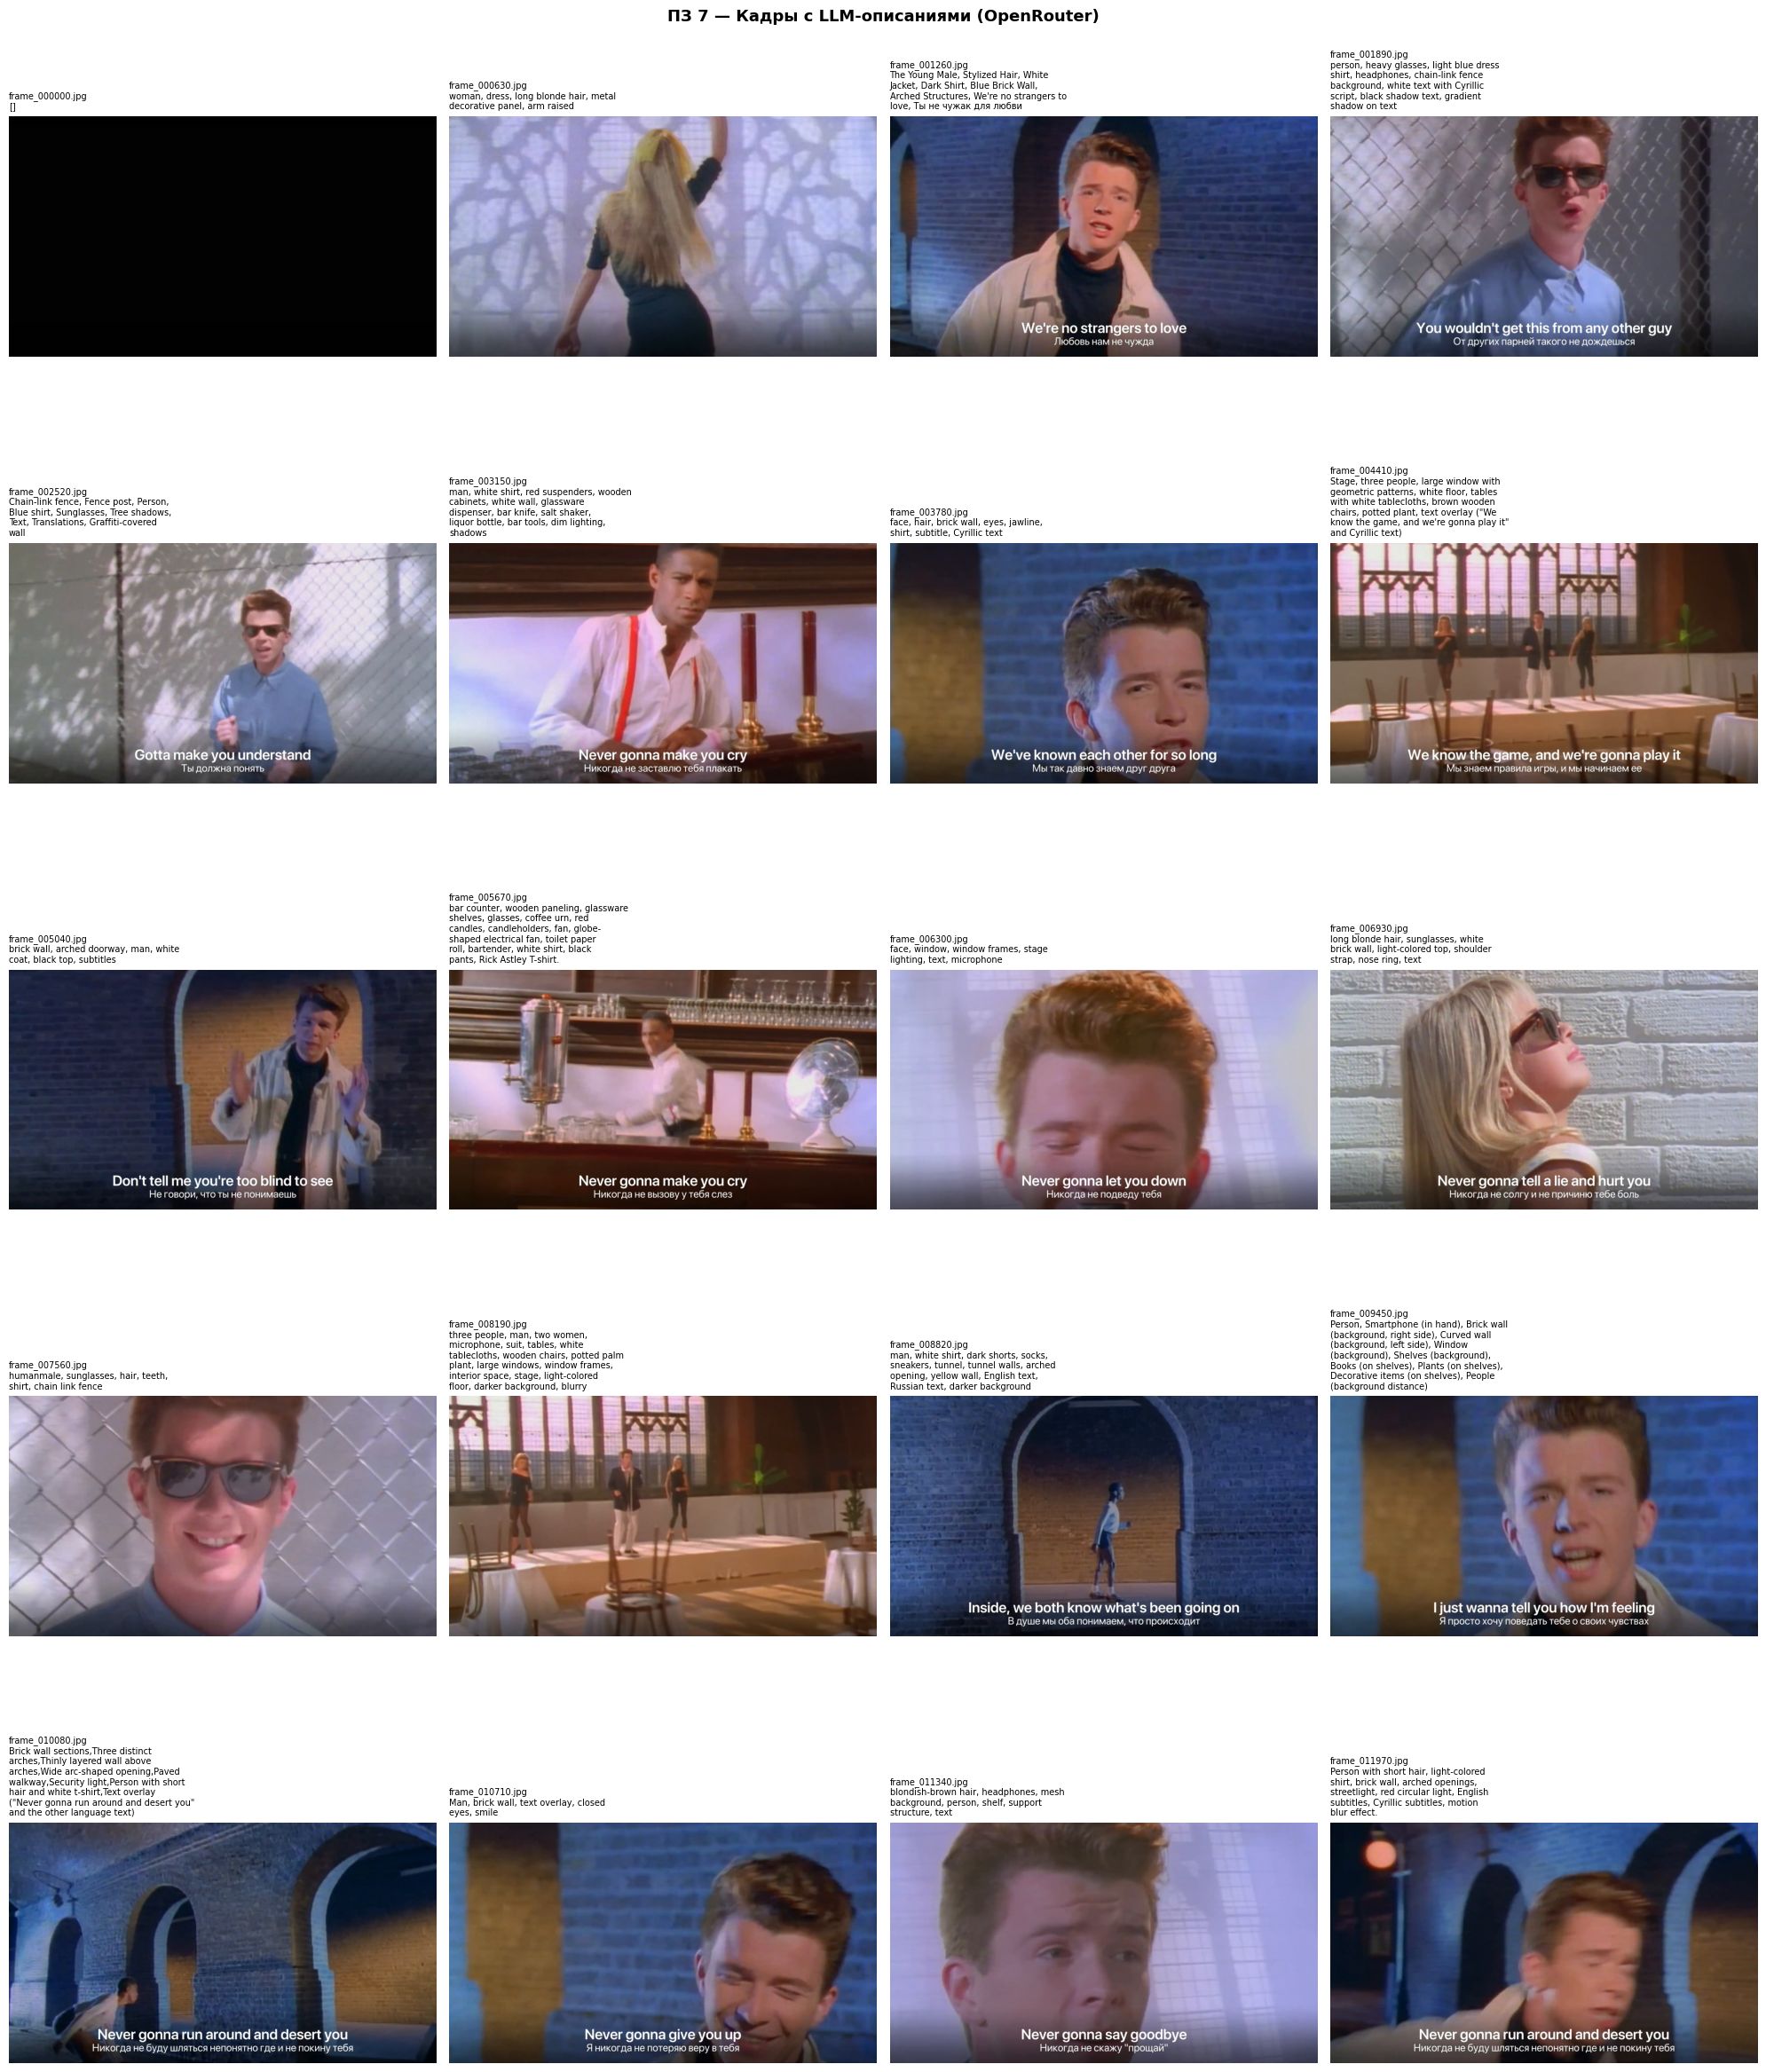

график сохранён: llm_summary.png


In [66]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import textwrap

# показываем обработанные кадры с описаниями
cols = 4
rows = (len(results) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 5))
axes = axes.flatten()

for i, item in enumerate(results):
    img_path = f'{FRAMES_DIR}/{item["frame"]}'
    try:
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
    except:
        axes[i].set_facecolor('#eee')

    axes[i].axis('off')
    caption = item.get('objects', 'ошибка')
    wrapped = '\n'.join(textwrap.wrap(caption, width=40))
    axes[i].set_title(f'{item["frame"]}\n{wrapped}', fontsize=7, loc='left')

# скрываем пустые ячейки
for j in range(len(results), len(axes)):
    axes[j].axis('off')

plt.suptitle('ПЗ 7 — Кадры с LLM-описаниями (OpenRouter)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/llm_summary.png', dpi=80, bbox_inches='tight')
plt.show()
print('график сохранён: llm_summary.png')
